In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# Credit Card Fraud Detection Using XGBoost

## Project Overview

Credit card fraud costs financial institutions and customers billions of dollars annually.
The core challenge is extreme class imbalance — fraudulent transactions account for less than 0.2% of all transactions,
making it easy for a naive model to achieve high accuracy simply by predicting everything as normal.

This project builds an end-to-end fraud detection pipeline using XGBoost.
The pipeline addresses class imbalance using SMOTE, and uses SHAP values to interpret model decisions.

## Problem Statement

Given a dataset of 284,807 credit card transactions made by European cardholders in September 2013,
the goal is to classify each transaction as fraudulent (1) or legitimate (0).

## Approach

- Exploratory Data Analysis to understand data distribution and class imbalance
- Preprocessing: scaling and SMOTE oversampling
- Model: XGBoost Classifier
- Evaluation: Precision-Recall AUC, ROC-AUC, F1-Score, and Confusion Matrix
- Explainability: SHAP feature importance

## Step 1: Import Libraries

We begin by importing all required libraries for data manipulation, visualization, modeling, and explainability.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             average_precision_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')


## Step 2: Load Data

We load the dataset directly from Kaggle's input directory and take an initial look at its structure.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 284,807 rows, 31 columns

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 2.5: Data Quality Check

Before any analysis, we verify the dataset has no missing values 
and check for duplicate rows, which can bias model training and evaluation.

In [5]:
print("--- Missing Values ---")
print(df.isnull().sum().sum(), "missing values total")

print("\n--- Duplicate Rows ---")
duplicates = df.duplicated().sum()
print(f"{duplicates:,} duplicate rows found ({duplicates/len(df)*100:.2f}%)")

print("\n--- Data Types ---")
print(df.dtypes.value_counts())

--- Missing Values ---
0 missing values total

--- Duplicate Rows ---
1,081 duplicate rows found (0.38%)

--- Data Types ---
float64    30
int64       1
Name: count, dtype: int64


## Step 2.6: Investigate Duplicates Before Dropping

We check how duplicate rows are distributed across both classes before removing them,
since dropping duplicates indiscriminately could disproportionately affect the already-rare fraud class.

In [6]:
dup_mask = df.duplicated()
print("--- Duplicate rows by class ---")
print(df[dup_mask]['Class'].value_counts())

print(f"\nTotal rows before: {len(df):,}")
df = df.drop_duplicates()
print(f"Total rows after:  {len(df):,}")

print("\n--- Class distribution after removing duplicates ---")
print(df['Class'].value_counts())
print(f"Fraud percentage: {df['Class'].mean()*100:.3f}%")

--- Duplicate rows by class ---
Class
0    1062
1      19
Name: count, dtype: int64

Total rows before: 284,807
Total rows after:  283,726

--- Class distribution after removing duplicates ---
Class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.167%


Out of 1,081 duplicate rows, only 19 belonged to the fraud class. Given that each transaction has 30 continuous numerical features, exact duplication across all features is statistically implausible for genuinely distinct transactions — these are data artifacts rather than separate fraud events. Removing them is justified and does not meaningfully affect the fraud ratio (0.172% → 0.167%).

## Step 3: Exploratory Data Analysis

We analyze class distribution, compare transaction amounts between fraud and 
normal transactions, and examine whether fraud follows any time-based pattern.

--- Class Distribution ---
Class
0    283253
1       473
Name: count, dtype: int64

Fraud percentage: 0.167%
Imbalance ratio: 1 fraud per 598 normal transactions

--- Amount Statistics by Class ---
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


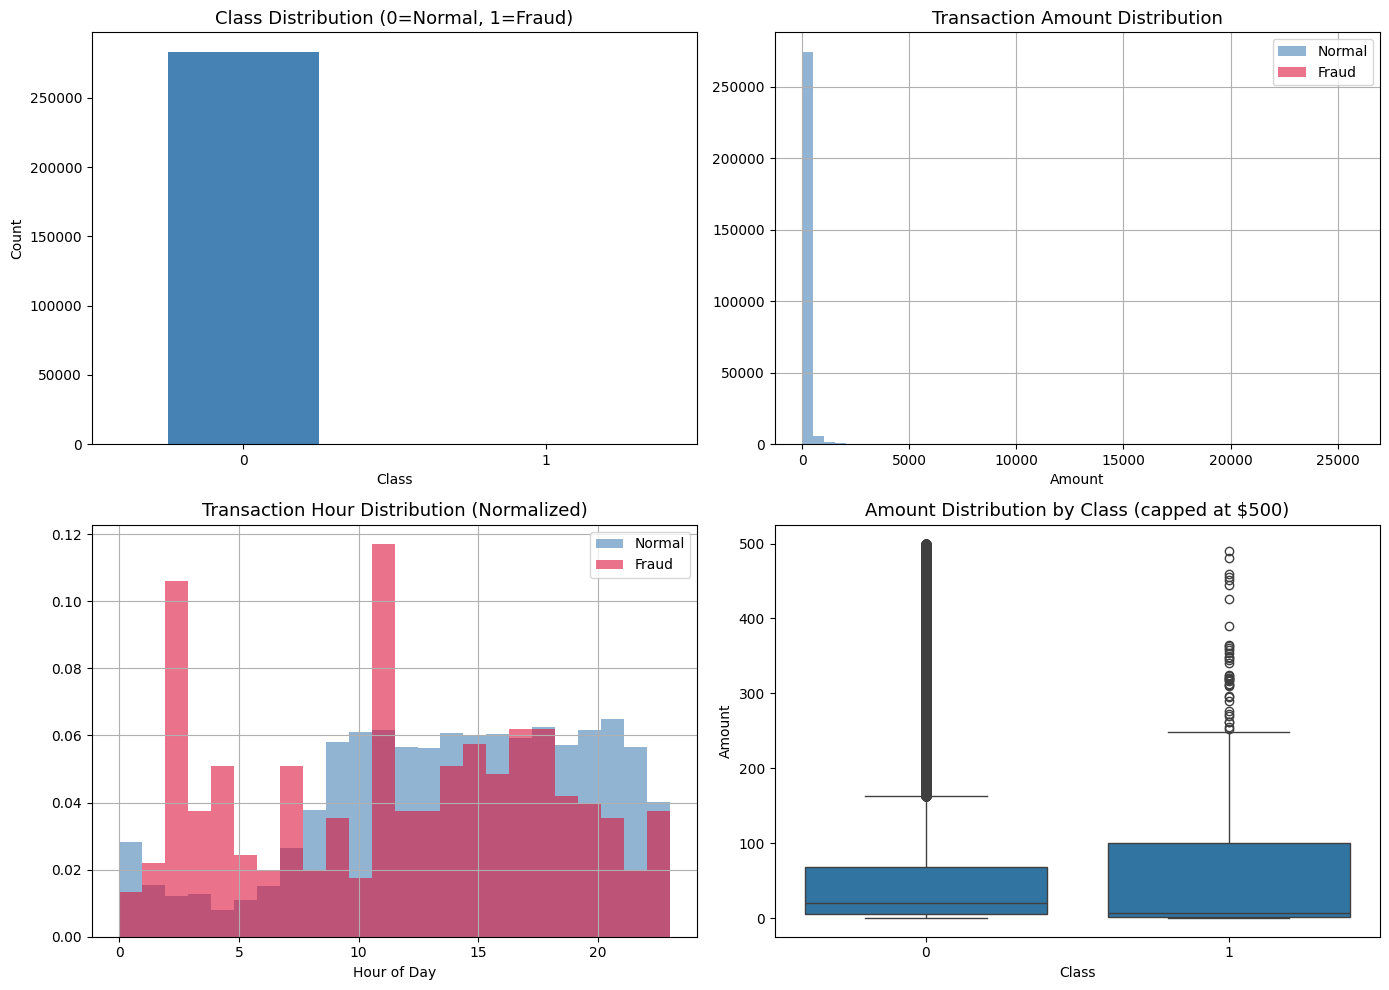

In [7]:
print("--- Class Distribution ---")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")
print(f"Imbalance ratio: 1 fraud per {class_counts[0]//class_counts[1]} normal transactions")

print("\n--- Amount Statistics by Class ---")
print(df.groupby('Class')['Amount'].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_counts.plot(kind='bar', ax=axes[0,0], color=['steelblue', 'crimson'])
axes[0,0].set_title('Class Distribution (0=Normal, 1=Fraud)', fontsize=13)
axes[0,0].set_xlabel('Class')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.6, ax=axes[0,1], color='steelblue', label='Normal')
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.6, ax=axes[0,1], color='crimson', label='Fraud')
axes[0,1].set_title('Transaction Amount Distribution', fontsize=13)
axes[0,1].set_xlabel('Amount')
axes[0,1].legend()

df['Hour'] = (df['Time'] % (24*3600)) // 3600
df[df['Class']==0]['Hour'].hist(bins=24, alpha=0.6, ax=axes[1,0], color='steelblue', label='Normal', density=True)
df[df['Class']==1]['Hour'].hist(bins=24, alpha=0.6, ax=axes[1,0], color='crimson', label='Fraud', density=True)
axes[1,0].set_title('Transaction Hour Distribution (Normalized)', fontsize=13)
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].legend()

sns.boxplot(data=df[df['Amount']<500], x='Class', y='Amount', ax=axes[1,1])
axes[1,1].set_title('Amount Distribution by Class (capped at $500)', fontsize=13)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

**Observations:**
- The dataset is highly imbalanced: 1 fraud case per ~598 normal transactions (0.167%).
- Fraud transactions show a lower median amount ($9.82 vs $22.00) but a higher mean 
  ($123.87 vs $88.41), suggesting most fraud attempts involve small amounts while a 
  small number of high-value fraud cases skew the average upward.
- Normal transactions reach much higher maximum amounts ($25,691 vs $2,125 for fraud), 
  indicating fraudsters tend to avoid very large transactions, likely to evade detection.
- Fraud transactions show distinct peaks at specific hours (around 2 AM and 11 AM), 
  unlike the more uniform distribution of normal transactions — suggesting time-of-day 
  could be a useful engineered feature.

## Step 4: Preprocessing

Based on the EDA findings, fraud transactions show distinct hourly patterns, 
so we keep the engineered `Hour` feature instead of discarding time information entirely.
We drop the raw `Time` column (a cumulative value with no standalone meaning), 
scale `Amount` and `Hour`, split the data, then apply SMOTE on the training set only 
to prevent data leakage.

In [9]:
df = df.drop('Time', axis=1)

scaler = StandardScaler()
df[['Amount', 'Hour']] = scaler.fit_transform(df[['Amount', 'Hour']])

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Features used: {X_train.shape[1]} (including engineered Hour)")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training samples: {len(X_train_res):,}")
print(f"Fraud:  {y_train_res.sum():,}")
print(f"Normal: {(y_train_res == 0).sum():,}")

Training set: 226,980 samples
Test set:     56,746 samples
Features used: 30 (including engineered Hour)

After SMOTE:
Training samples: 453,204
Fraud:  226,602
Normal: 226,602


## Step 5: Model Training

We train an XGBoost classifier on the SMOTE-balanced training set.
The evaluation metric is set to `aucpr` (Area Under the Precision-Recall Curve),
which is far more informative than accuracy on imbalanced data — a model that 
predicts "normal" for everything would still score ~99.8% accuracy while being useless.

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("Training complete")

Training XGBoost...
[0]	validation_0-aucpr:0.49394
[50]	validation_0-aucpr:0.67855
[100]	validation_0-aucpr:0.76247
[150]	validation_0-aucpr:0.77337
[200]	validation_0-aucpr:0.79152
[250]	validation_0-aucpr:0.79985
[299]	validation_0-aucpr:0.80267
Training complete


**Observations:**
- The model's PR-AUC improved steadily from 0.494 to 0.803 across training, 
  with no signs of overfitting (consistent improvement, no oscillation).
- The curve begins to plateau after iteration ~250, suggesting 300 estimators 
  is near the point of diminishing returns for this configuration.

## Step 6: Evaluation

We evaluate the model on the real, imbalanced test set (not the SMOTE-balanced one).
For imbalanced fraud detection, Precision-Recall AUC matters more than overall accuracy.

- **Precision**: Of all transactions flagged as fraud, how many were actually fraud?
- **Recall**: Of all actual fraud cases, how many did the model catch?

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.61      0.80      0.69        95

    accuracy                           1.00     56746
   macro avg       0.81      0.90      0.85     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score:       0.9757
Avg Precision Score: 0.8029


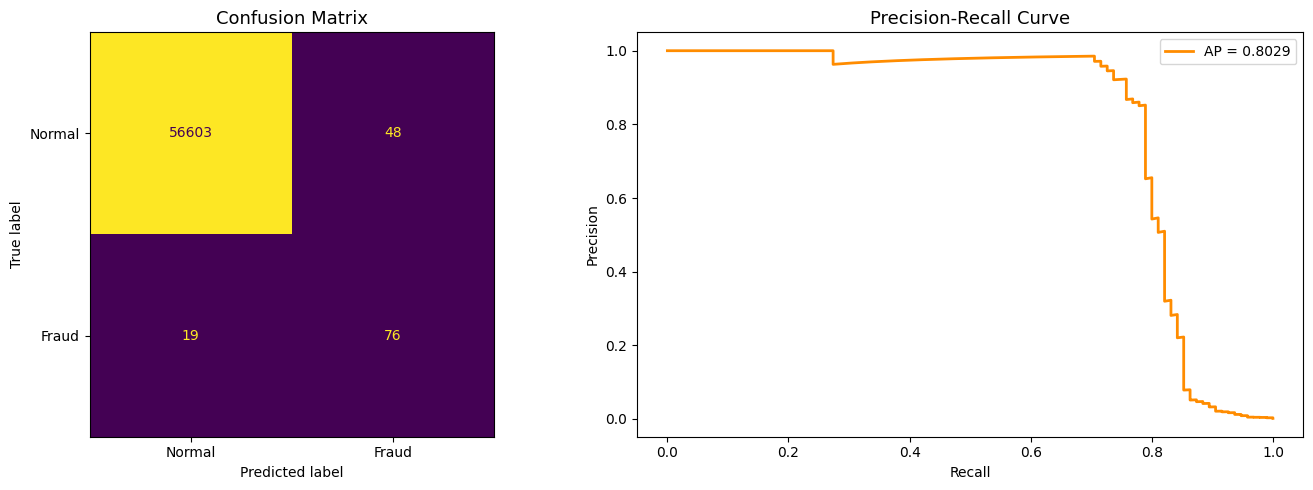

In [11]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score:       {roc_auc:.4f}")
print(f"Avg Precision Score: {avg_precision:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'AP = {avg_precision:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()

**Observations:**
- Overall accuracy (100%) is misleading due to severe class imbalance — a naive 
  "always predict normal" model would also score ~99.8% accuracy. PR-AUC (0.8029) 
  and ROC-AUC (0.9757) are the meaningful metrics here.
- The model catches 76 of 95 fraud cases (80% recall) at the cost of 48 false alarms 
  (61% precision). In a real banking context, this trade-off is generally acceptable: 
  the cost of missing fraud outweighs the cost of reviewing a false alarm.
- 19 fraud cases were missed entirely (false negatives) — these represent the 
  highest-priority cases for further investigation or model improvement.

## Step 6.5: Threshold Tuning

The default classification threshold (0.5) is not necessarily optimal for fraud detection,
where missing a fraud case (false negative) is typically more costly than a false alarm.
We test multiple thresholds to find a better operating point that favors recall 
without excessively sacrificing precision.

    threshold  precision  recall     f1
0        0.10      0.176   0.853  0.292
1        0.15      0.240   0.842  0.373
2        0.20      0.299   0.832  0.440
3        0.25      0.359   0.821  0.500
4        0.30      0.404   0.821  0.542
5        0.35      0.484   0.821  0.609
6        0.40      0.538   0.811  0.647
7        0.45      0.589   0.800  0.679
8        0.50      0.613   0.800  0.694
9        0.55      0.644   0.800  0.714
10       0.60      0.664   0.789  0.721
11       0.65      0.688   0.789  0.735
12       0.70      0.714   0.789  0.750
13       0.75      0.743   0.789  0.765
14       0.80      0.798   0.789  0.794
15       0.85      0.859   0.768  0.811
16       0.90      0.922   0.747  0.826


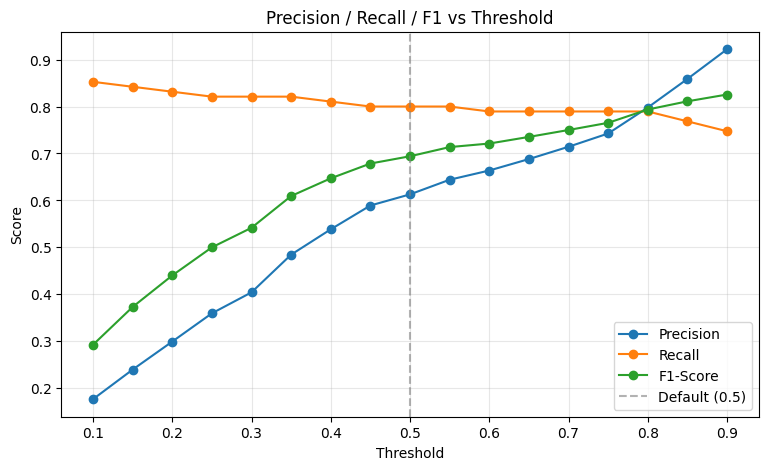

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results)
print(results_df.round(3))

plt.figure(figsize=(9, 5))
plt.plot(results_df['threshold'], results_df['precision'], marker='o', label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], marker='o', label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], marker='o', label='F1-Score')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()

**Observations:**
- Precision and Recall curves intersect around threshold ≈ 0.80, the point of 
  maximum F1-score.
- However, Recall remains nearly flat (0.80–0.85) for thresholds between 0.10 and 0.50, 
  while Precision collapses sharply (0.61 → 0.18) over the same range.
- This means lowering the threshold below 0.5 yields almost no practical recall gain 
  at a severe precision cost. The default threshold (0.5) is therefore retained as 
  the operating point: Precision = 0.613, Recall = 0.800.

## Step 7: Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) explains individual model predictions by 
quantifying how much each feature contributed, and in which direction, to the 
final fraud probability. This turns the model from a black box into an 
interpretable tool — a critical requirement in real-world financial fraud systems, 
where decisions must be explainable to regulators and customers.

Calculating SHAP values...


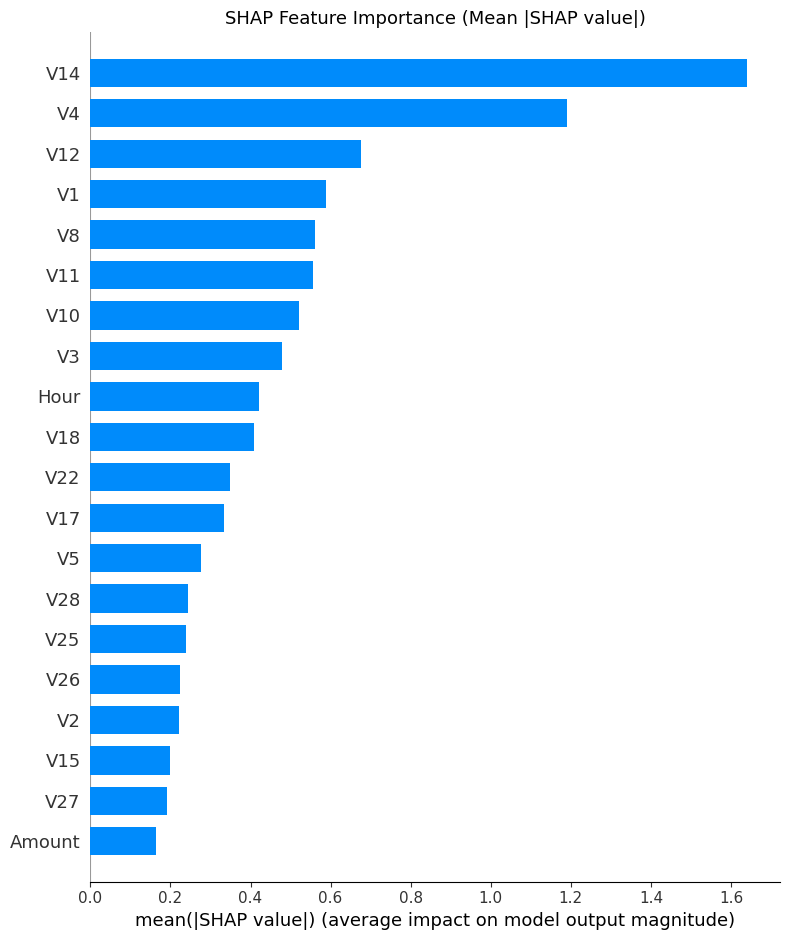

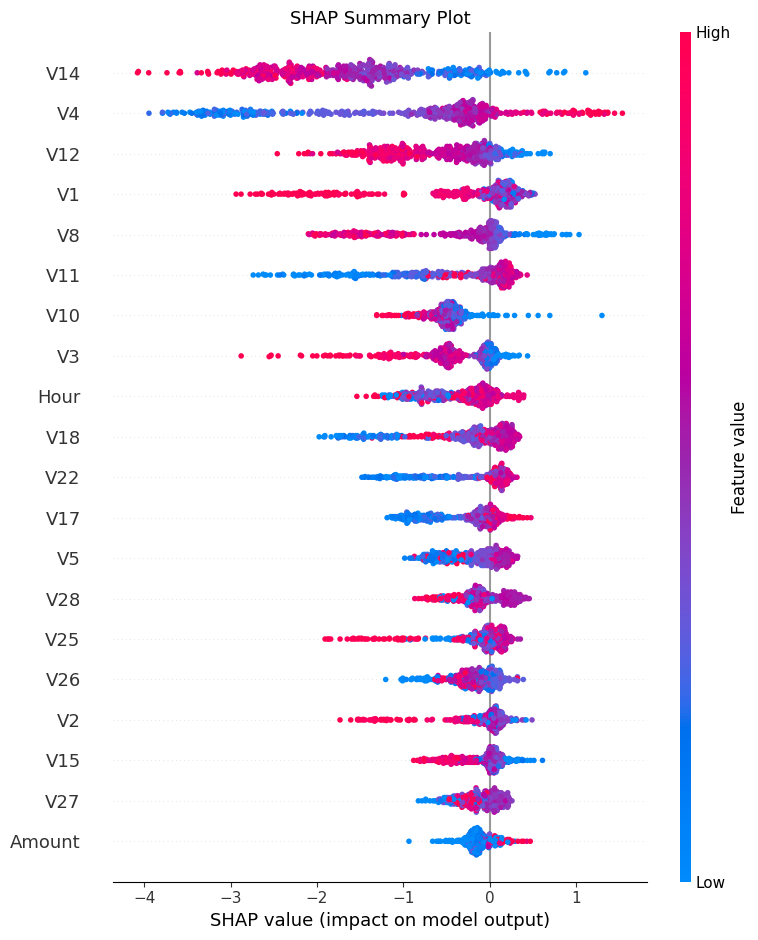

In [13]:
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:500], show=False)
plt.title('SHAP Summary Plot', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

**Observations:**
- V14, V4, and V12 are the most influential features in fraud detection, far 
  ahead of the rest — though as PCA-anonymized components, their real-world 
  meaning cannot be directly interpreted.
- The engineered `Hour` feature ranks 9th out of 30 in importance, validating 
  the earlier EDA-driven decision to retain time-of-day information rather than 
  discarding it.
- Notably, `Amount` — often assumed to be a strong fraud indicator — ranks as 
  the **least** important feature, challenging the intuitive assumption that 
  larger transactions are more likely to be fraudulent.
- For V14, low feature values push predictions toward fraud, while high values 
  push toward normal, as shown by the color gradient in the summary plot.

## Step 8: Save the Model

We save the trained model and the fitted scaler, since any future predictions 
on new data must use the exact same scaling transformation applied during training.

In [14]:
with open('xgb_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as xgb_fraud_model.pkl")
print("Scaler saved as scaler.pkl")
print("\nPipeline complete.")

Model saved as xgb_fraud_model.pkl
Scaler saved as scaler.pkl

Pipeline complete.
